# P-wave-earthquake-localisation-toy-box exemple notebook

In [1]:
import numpy as np

In [2]:
import generate_eq
import graphics
import commons

In [3]:
import Gauss_Newton
import Levenberg_Marquardt

In [4]:

# Deffine the stations, world box and V-P
#                        X       Y     Z    t
stations = np.array([[   0.0,  700.0,  0.0, 0.0],  # N°1
                     [ 700.0, 1000.0,  0.0, 0.0],  # N°2
                     [1000.0,  300.0,  0.0, 0.0],  # N°3
                     [ 500.0,  500.0, 10.0, 0.0],  # N°4
                     [ 400.0,    0.0,  0.0, 0.0]]) # N°5

box_gen = np.array([[    0.0,  1000.0],
                    [    0.0,  1000.0],
                    [-1000.0,     0.0]])

vp = 4000.0 # m/s

# Generate a random event without any noise
event, event_arr, stations, stations_true = generate_eq.generate_event(stations, box_gen, vp, 0.0)
print(f'Event before normalisation:\n\t{event}\n')

# Normalise the stations
stations_norm, event_norm = commons.centrering_arr(stations, event_arr)
event_norm_dict = {'X':float(event_norm[0]), 'Y':float(event_norm[1]),
                   'Z':float(event_norm[2]), 't':float(event_norm[3])}

print(f'Event after normalisation:\n\t{event_norm_dict}\n')

# Compute the normalised world box
limites = np.column_stack((np.min(stations_norm, axis=0), np.max(stations_norm, axis=0)))

# Set the initialisation to be the same for all iterative solver
event_ini = np.random.rand(4)
event_ini = limites[:, 0] + event_ini * (limites[:, 1]-limites[:, 0])
event_ini[2] = min(event_ini[2], -1)
event_ini_dict = {'X':float(event_ini[0]), 'Y':float(event_ini[1]),
                  'Z':float(event_ini[2]), 't':float(event_ini[3])}

print(f'Initialisation:\n\t{event_ini_dict}\n')


Event before normalisation:
	{'X': 402.0177024308123, 'Y': 193.6446994159754, 'Z': -679.1042805838133, 't': 1785158782.355417}

Event after normalisation:
	{'X': -97.98229756918772, 'Y': -306.3553005840246, 'Z': -689.1042805838133, 't': -0.19011807441711426}

Initialisation:
	{'X': -396.1259413398623, 'Y': 465.65684034080823, 'Z': -5.101224260321791, 't': 0.03724025638881775}



Best fitt with:
	- RMSE = 7.007676614932553e-08
	- Event = {'X': -97.98193299047307, 'Y': -306.3544577129823, 'Z': -689.1031008729977, 't': -0.19011780142618181}


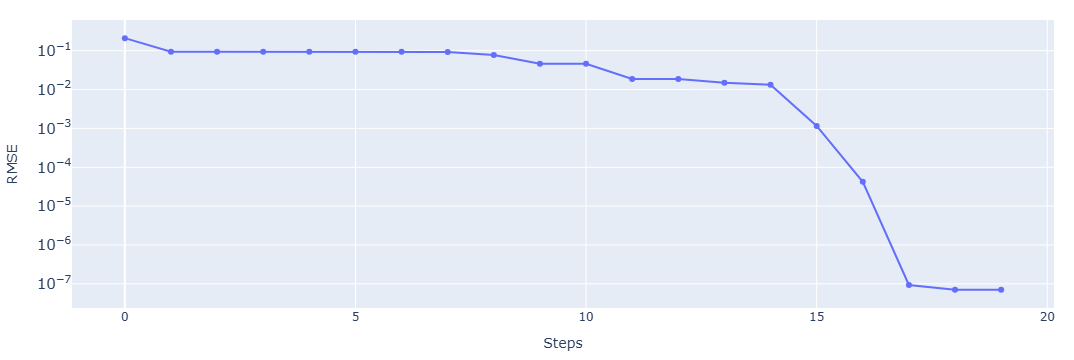

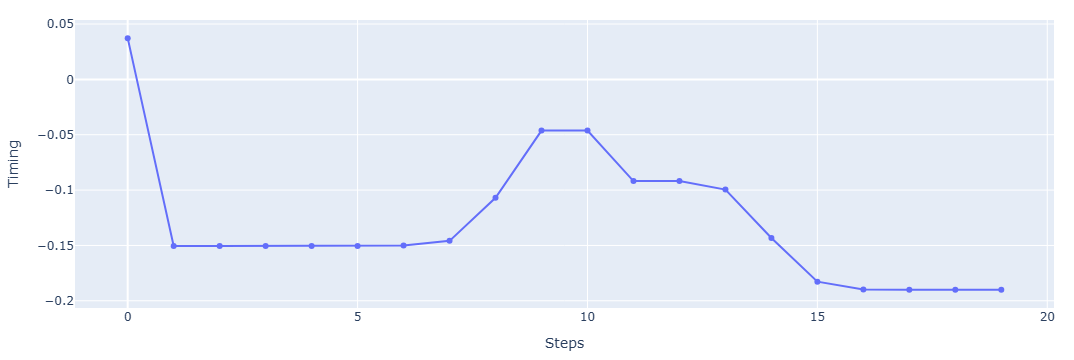

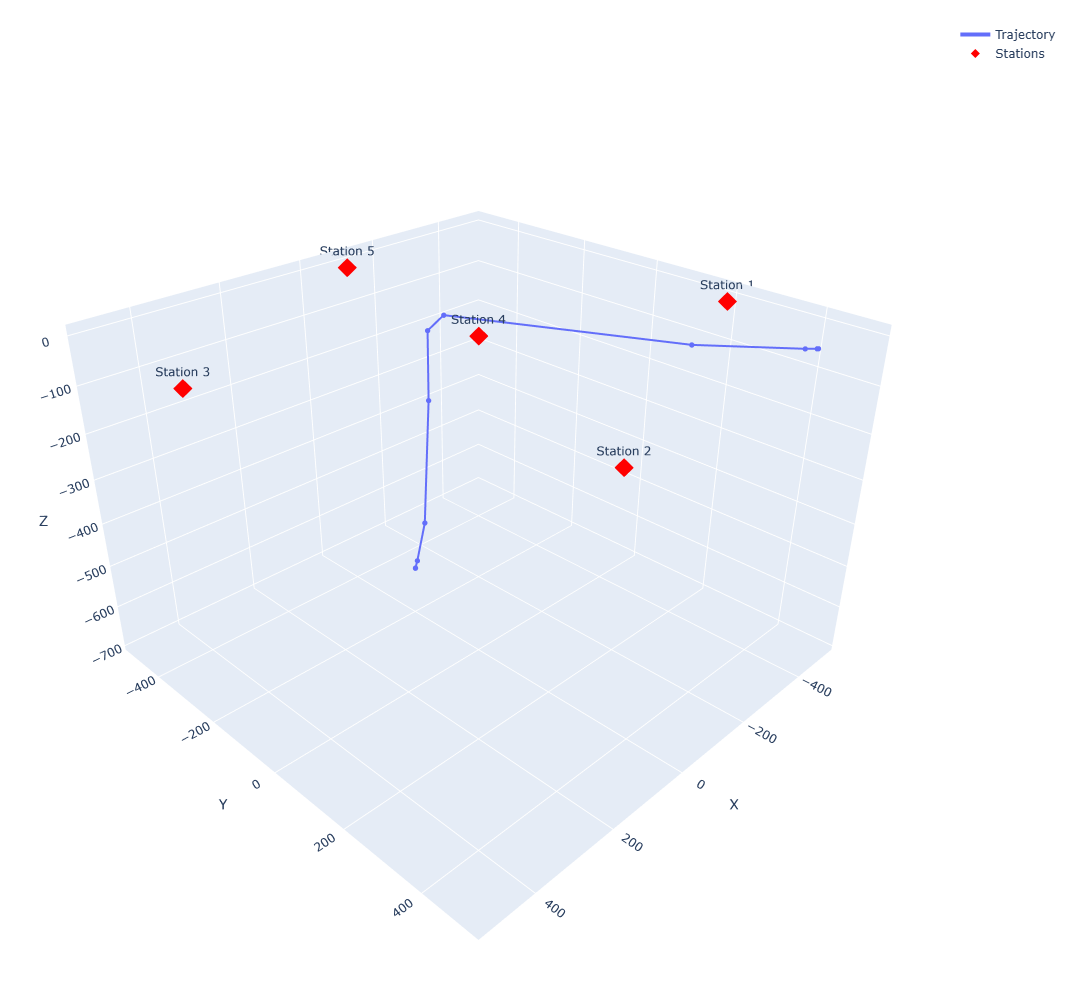

In [5]:
event_best_GN, history_GN, cost_story_GN, misfit_fin_GN = Gauss_Newton.Gauss_Newton(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=1_000,
    steps=np.array([1.0, 1.0, 1.0, 0.0005]),
    vp=vp)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_GN}')
print(f'\t- Event = {event_best_GN}')

_ = graphics.history_2d(cost_story_GN, 'RMSE', log_y=True)
_ = graphics.history_2d(history_GN[:, 3], 'Timing')
_ = graphics.history_3d(history_GN[:, :3], stations_norm)

Best fitt with:
	- RMSE = 7.007676612694529e-08
	- Event = {'X': -97.98193299045884, 'Y': -306.354457712941, 'Z': -689.1031008728608, 't': -0.190117801426151}


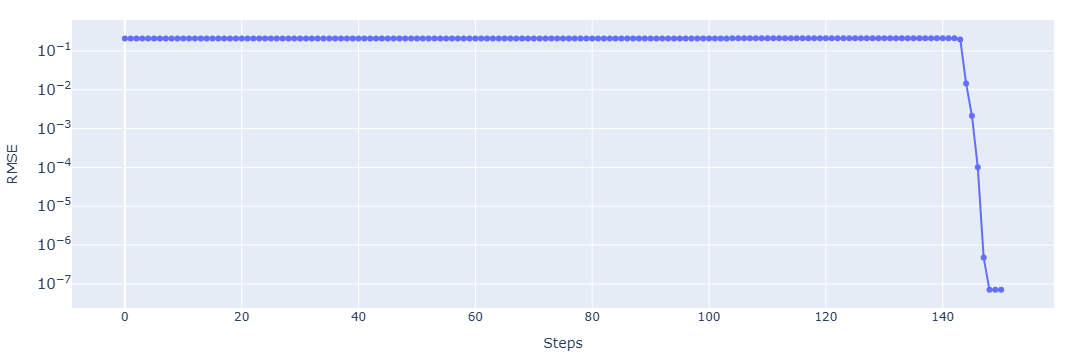

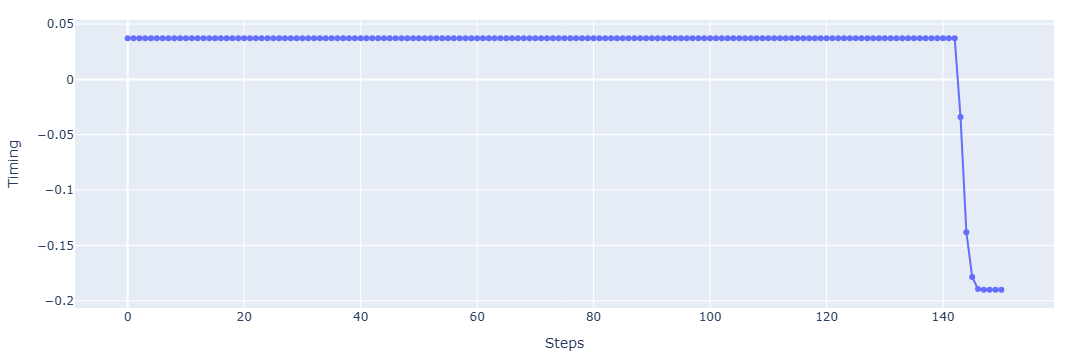

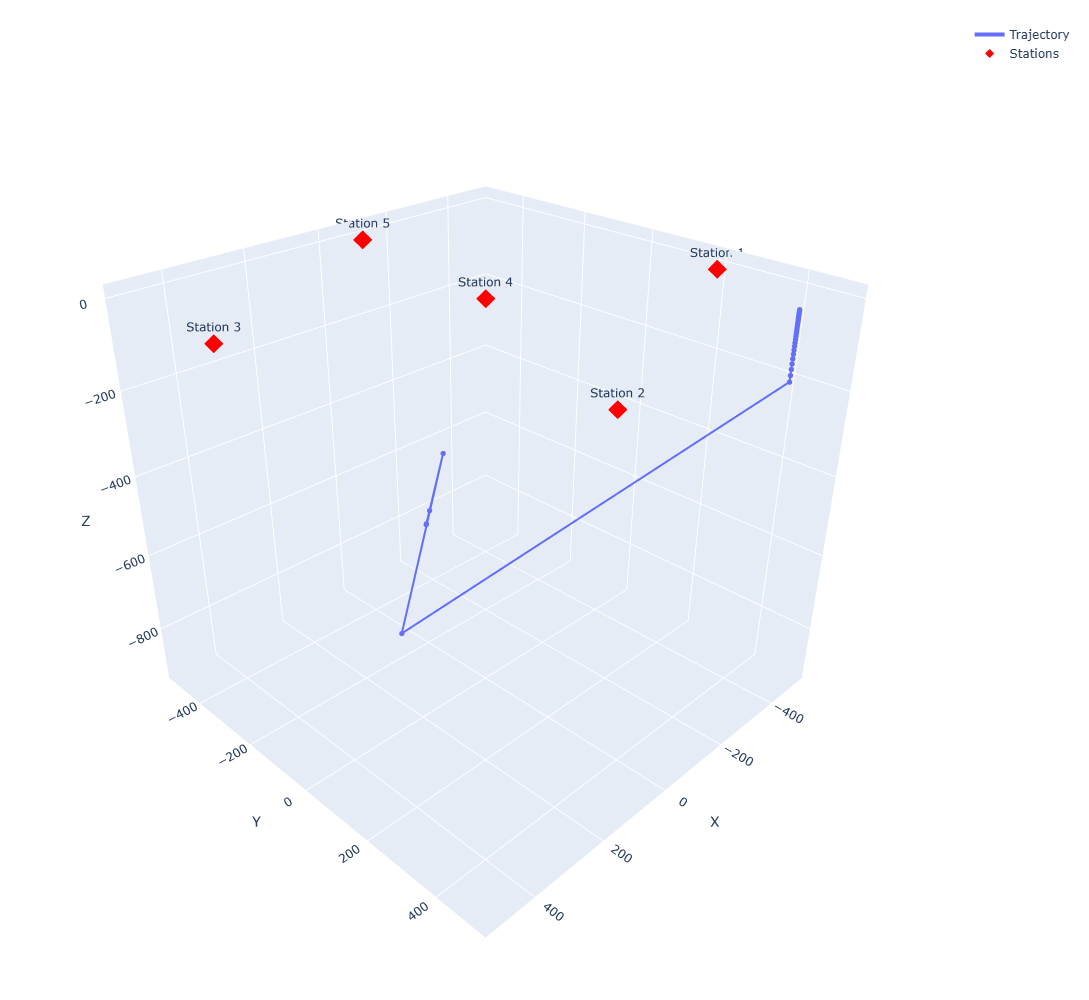

In [6]:
event_best_LM, history_LM, cost_story_LM, misfit_fin_LM = Levenberg_Marquardt.Levenberg_Marquardt(
    stations=stations_norm,
    event_test=np.copy(event_ini),
    n_iteration=1_000,
    vp=vp)

print('Best fitt with:')
print(f'\t- RMSE = {misfit_fin_LM}')
print(f'\t- Event = {event_best_LM}')

_ = graphics.history_2d(cost_story_LM, 'RMSE', log_y=True)
_ = graphics.history_2d(history_LM[:, 3], 'Timing')
_ = graphics.history_3d(history_LM[:, :3], stations_norm)